# 20 — CART Global Surrogate Model — Helpdesk

Trains an interpretable decision tree (CART) to approximate the LSTM's
next-activity predictions across all inputs. Reveals **model-level** decision
logic — which features and thresholds drive the model's behaviour globally.

Uses engineered aggregate features (prefix-level statistics) rather than
raw per-position values.

In [1]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))

src_path = str(_current / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

In [2]:
import torch
import numpy as np
import pandas as pd

# --- Load dataset ---
data_path = _current / 'encoded_data' / 'test_philipp' / 'helpdesk_all_5_test.pkl'
dataset = torch.load(data_path, weights_only=False)

sample = dataset[0]
n_cat = len(sample[0])
n_num = len(sample[1])
seq_len = sample[0][0].shape[0]
print(f'Dataset: {len(dataset)} sequences, {n_cat} cat, {n_num} num, seq_len={seq_len}')

# --- Load model ---
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM

model_path = (_current / 'src' / 'notebooks' / 'training_variational_dropout'
              / 'Helpdesk' / 'Helpdesk_full_grad_norm_new_4layer.pkl')
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(model_path), dropout=0.0)
model.eval()

# --- TensorDecoder + activity vocab ---
from src.interpretability.utils.tensor_decoder import TensorDecoder

decoder = TensorDecoder(dataset)

ACTIVITY_FEATURE = 'Activity'
activity_idx_to_label = decoder.idx_to_label[ACTIVITY_FEATURE]
max_idx = max(activity_idx_to_label.keys())
activity_names = [activity_idx_to_label.get(i, f'<unk_{i}>') for i in range(max_idx + 1)]
eos_idx = next(i for i, name in enumerate(activity_names) if name == 'EOS')

# --- Predictor ---
from src.interpretability.perturbation_methods.revised_plus.revised_plus import RevisedPlusModelPredictor

predictor = RevisedPlusModelPredictor(model, suffix_step=0, activity_feature=ACTIVITY_FEATURE)

print(f'Model: {sum(p.numel() for p in model.parameters()):,} parameters')
print(f'Activity vocabulary ({len(activity_names)}), EOS={eos_idx}')
print(f'Cat features: {decoder.cat_features}')
print(f'Num features: {decoder.num_features}')

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

Dataset: 6077 sequences, 12 cat, 4 num, seq_len=18
Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('VariantIndex', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/lark/utils.py:163: DeprecationWarning: module 'sre_parse' is deprecated
  import sre_parse
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/lark/utils.py:164: DeprecationWarning: module 'sre_constants' is deprecated
  import sre_constants


Model: 1,035,015 parameters
Activity vocabulary (16), EOS=5
Cat features: ['Activity', 'Resource', 'Variant index', 'seriousness', 'customer', 'product', 'responsible_section', 'seriousness_2', 'service_level', 'service_type', 'support_section', 'workgroup']
Num features: ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day']


In [3]:
# Feature indices
ACT_IDX = 0    # Activity
RES_IDX = 1    # Resource
VAR_IDX = 2    # Variant index (case-level)

elapsed_num_idx = decoder.num_features.index('case_elapsed_time')
event_num_idx = decoder.num_features.index('event_elapsed_time')


def extract_features(cat_tuple, num_tuple, decoder):
    """Extract engineered aggregate features from a single prefix."""
    act_tensor = cat_tuple[ACT_IDX]
    mask = act_tensor != 0
    prefix_len = int(mask.sum().item())
    if prefix_len == 0:
        return None

    nonzero = mask.nonzero(as_tuple=True)[0]
    start = nonzero[0].item()
    end = start + prefix_len

    acts = act_tensor[start:end]

    # Trailing repetitions of last activity
    last_act = acts[-1].item()
    repeated = 1
    for k in range(len(acts) - 2, -1, -1):
        if acts[k].item() == last_act:
            repeated += 1
        else:
            break

    # Time features (inverse-transformed)
    total_elapsed = decoder.decode_numerical_value(
        'case_elapsed_time', num_tuple[elapsed_num_idx][end - 1].item())
    last_event_dur = decoder.decode_numerical_value(
        'event_elapsed_time', num_tuple[event_num_idx][end - 1].item())
    event_durs = [decoder.decode_numerical_value(
        'event_elapsed_time', num_tuple[event_num_idx][j].item())
        for j in range(start, end)]
    mean_event_dur = float(np.mean(event_durs))

    # Resource features
    res_tensor = cat_tuple[RES_IDX]
    resources = res_tensor[start:end].tolist()
    n_unique_res = len(set(resources))

    return {
        'prefix_length': prefix_len,
        'last_activity': decoder.decode_categorical_value(ACT_IDX, acts[-1].item()),
        'first_activity': decoder.decode_categorical_value(ACT_IDX, acts[0].item()),
        'n_unique_activities': len(set(acts.tolist())),
        'last_activity_repeated': repeated,
        'total_elapsed_time': total_elapsed,
        'last_event_duration': last_event_dur,
        'mean_event_duration': mean_event_dur,
        'variant_index': str(decoder.decode_categorical_value(VAR_IDX, cat_tuple[VAR_IDX][end - 1].item())),
        'last_resource': decoder.decode_categorical_value(RES_IDX, res_tensor[end - 1].item()),
        'n_unique_resources': n_unique_res,
        'resource_changed': int(n_unique_res > 1),
    }


# Quick test
sample_feats = extract_features(dataset[0][0], dataset[0][1], decoder)
print('Sample features:')
for k, v in sample_feats.items():
    print(f'  {k}: {v}')

Sample features:
  prefix_length: 5
  last_activity: EOS
  first_activity: Assign seriousness
  n_unique_activities: 5
  last_activity_repeated: 1
  total_elapsed_time: 1156142.7500000005
  last_event_duration: 963303.3124999997
  mean_event_duration: 1404936.3469515385
  variant_index: <none>
  last_resource: EOS
  n_unique_resources: 4
  resource_changed: 1


In [4]:
# Collect unique cases (keep entry with longest trace)
print('Scanning for unique cases...')
cases = {}
for i in range(len(dataset)):
    cat_t, num_t, case_id = dataset[i]
    trace_len = int((cat_t[0] != 0).sum().item())
    if case_id not in cases or trace_len > cases[case_id][1]:
        cases[case_id] = (i, trace_len)

print(f'Found {len(cases)} unique cases')

# Slice each case into prefixes of varying lengths.
# Strip trailing EOS so prefixes end with real activities and
# the LSTM gives diverse (non-trivial) predictions.
feature_rows = []
sliced_cat_list = []
sliced_num_list = []

for case_id, (ds_idx, trace_len) in cases.items():
    cat_full, num_full, _ = dataset[ds_idx]
    src_start = seq_len - trace_len  # where non-padding starts

    # Find useful trace length (strip trailing EOS)
    acts = cat_full[ACT_IDX][src_start:src_start + trace_len]
    useful_len = trace_len
    for j in range(trace_len - 1, -1, -1):
        if acts[j].item() == eos_idx:
            useful_len = j
        else:
            break
    if useful_len == 0:
        continue

    # Generate prefixes of length 1 .. useful_len
    for k in range(1, useful_len + 1):
        pad_len = seq_len - k
        cat_prefix = []
        for c in cat_full:
            t = torch.zeros_like(c)
            t[pad_len:] = c[src_start:src_start + k]
            cat_prefix.append(t)

        num_prefix = []
        for n in num_full:
            t = torch.zeros_like(n)
            t[pad_len:] = n[src_start:src_start + k]
            num_prefix.append(t)

        feats = extract_features(tuple(cat_prefix), tuple(num_prefix), decoder)
        if feats is not None:
            feature_rows.append(feats)
            sliced_cat_list.append(cat_prefix)
            sliced_num_list.append(num_prefix)

X = pd.DataFrame(feature_rows)
N_total = len(X)
print(f'Generated {N_total} prefixes from {len(cases)} cases')
print(f'\nPrefix length distribution:')
print(X['prefix_length'].value_counts().sort_index())
display(X.describe(include='all'))

# --- Batch-predict LSTM labels ---
print(f'\nBatch-predicting with LSTM...')
cat_batch = [
    torch.stack([sliced_cat_list[i][ci] for i in range(N_total)])
    for ci in range(n_cat)
]
num_stacked = torch.stack([
    torch.stack(sliced_num_list[i], dim=-1)
    for i in range(N_total)
])

preds, probs = predictor.predict_batch(cat_batch, num_stacked, batch_size=128)
y = np.array([activity_names[p] for p in preds])

print(f'\nLSTM prediction distribution:')
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in sorted(zip(unique, counts), key=lambda x: -x[1]):
    print(f'  {cls}: {cnt} ({cnt / len(y) * 100:.1f}%)')

Scanning for unique cases...
Found 916 unique cases
Generated 4245 prefixes from 916 cases

Prefix length distribution:
prefix_length
1     916
2     916
3     916
4     878
5     357
6     148
7      66
8      29
9      12
10      4
11      2
12      1
Name: count, dtype: int64


,prefix_length,last_activity,first_activity,n_unique_activities,last_activity_repeated,total_elapsed_time,last_event_duration,mean_event_duration,variant_index,last_resource,n_unique_resources,resource_changed
count,4245.000000,4245,4245,4245.000000,4245.000000,4.245000e+03,4.245000e+03,4.245000e+03,4245,4245,4245.000000,4245.000000
unique,NaN,13,4,NaN,NaN,NaN,NaN,NaN,57,22,NaN,NaN
top,NaN,Take in charge ticket,Assign seriousness,NaN,NaN,NaN,NaN,NaN,1.0,Value 2,NaN,NaN
freq,NaN,996,4018,NaN,NaN,NaN,NaN,NaN,1972,876,NaN,NaN
mean,2.958068,NaN,NaN,2.646408,1.052061,1.191361e+06,9.804137e+05,7.601588e+05,NaN,NaN,1.826620,0.577856
std,1.597339,NaN,NaN,1.245374,0.251992,1.498739e+06,1.111711e+06,3.246116e+05,NaN,NaN,0.852505,0.493959
min,1.000000,NaN,NaN,1.000000,1.000000,7.060165e-02,1.007044e+00,1.377405e+05,NaN,NaN,1.000000,0.000000
25%,2.000000,NaN,NaN,2.000000,1.000000,2.408049e+01,1.478902e+04,4.816821e+05,NaN,NaN,1.000000,0.000000
50%,3.000000,NaN,NaN,3.000000,1.000000,2.852810e+05,9.633033e+05,7.802053e+05,NaN,NaN,2.000000,1.000000
75%,4.000000,NaN,NaN,4.000000,1.000000,2.535687e+06,1.296014e+06,9.633033e+05,NaN,NaN,2.000000,1.000000



Batch-predicting with LSTM...

LSTM prediction distribution:
  Resolve ticket: 1501 (35.4%)
  Closed: 995 (23.4%)
  EOS: 915 (21.6%)
  Take in charge ticket: 834 (19.6%)


In [5]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

# Identify categorical vs numerical columns
cat_cols = [c for c in X.columns if X[c].dtype == 'object']
num_cols = [c for c in X.columns if c not in cat_cols]
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print(f'Numerical columns ({len(num_cols)}): {num_cols}')

# Ordinal-encode categoricals (CART handles ordinal splits natively)
ord_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_encoded = X.copy()
X_encoded[cat_cols] = ord_encoder.fit_transform(X[cat_cols].astype(str))

cat_mappings = {}
for i, col in enumerate(cat_cols):
    cat_mappings[col] = list(ord_encoder.categories_[i])
    print(f'  {col}: {len(cat_mappings[col])} categories')

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y)
print(f'\nTrain: {len(X_train)}, Test: {len(X_test)}')

Categorical columns (4): ['last_activity', 'first_activity', 'variant_index', 'last_resource']
Numerical columns (8): ['prefix_length', 'n_unique_activities', 'last_activity_repeated', 'total_elapsed_time', 'last_event_duration', 'mean_event_duration', 'n_unique_resources', 'resource_changed']
  last_activity: 13 categories
  first_activity: 4 categories
  variant_index: 57 categories
  last_resource: 22 categories

Train: 3396, Test: 849


In [6]:
from sklearn.tree import DecisionTreeClassifier

# min_samples_leaf: increase to reduce scatter (fewer, larger leaves)
MIN_SAMPLES_LEAF = 20

depths = [3, 4, 5, 6, 8, None]
results = []

for depth in depths:
    clf = DecisionTreeClassifier(
        max_depth=depth, min_samples_leaf=MIN_SAMPLES_LEAF, random_state=42)
    clf.fit(X_train, y_train)
    train_fid = clf.score(X_train, y_train)
    test_fid = clf.score(X_test, y_test)
    n_leaves = clf.get_n_leaves()
    results.append({
        'max_depth': depth if depth is not None else 'None',
        'min_samples_leaf': MIN_SAMPLES_LEAF,
        'train_fidelity': f'{train_fid:.4f}',
        'test_fidelity': f'{test_fid:.4f}',
        'n_leaves': n_leaves,
        'model': clf,
    })
    print(f'depth={str(depth):>4s}  train={train_fid:.4f}  test={test_fid:.4f}  leaves={n_leaves}')

df_results = pd.DataFrame([{k: v for k, v in r.items() if k != 'model'} for r in results])
display(df_results)

# Select best depth: prefer shallower when fidelity difference < 2%
best_idx = 0
best_test = float(results[0]['test_fidelity'])
for i in range(1, len(results)):
    ti = float(results[i]['test_fidelity'])
    if ti > best_test + 0.02:
        best_idx = i
        best_test = ti

best = results[best_idx]
clf_best = best['model']
print(f'\nSelected: depth={best["max_depth"]} (test fidelity={best["test_fidelity"]}, '
      f'leaves={best["n_leaves"]})')

if float(best['test_fidelity']) < 0.60:
    print('\nWARNING: Fidelity below 60% -- surrogate may not be meaningful!')
elif float(best['test_fidelity']) < 0.70:
    print('\nNote: Fidelity below 70% -- interpret surrogate rules with caution.')

depth=   3  train=0.8584  test=0.8516  leaves=8
depth=   4  train=0.8822  test=0.8669  leaves=14
depth=   5  train=0.8910  test=0.8763  leaves=22
depth=   6  train=0.9005  test=0.8881  leaves=33
depth=   8  train=0.9273  test=0.9105  leaves=49
depth=None  train=0.9273  test=0.9105  leaves=55


,max_depth,min_samples_leaf,train_fidelity,test_fidelity,n_leaves
0,3,20,0.8584,0.8516,8
1,4,20,0.8822,0.8669,14
2,5,20,0.8910,0.8763,22
3,6,20,0.9005,0.8881,33
4,8,20,0.9273,0.9105,49
5,None,20,0.9273,0.9105,55



Selected: depth=8 (test fidelity=0.9105, leaves=49)


DEBUG:matplotlib:CACHEDIR=/Users/philippeichhorn/.matplotlib
DEBUG:matplotlib.font_manager:Using fontManager instance from /Users/philippeichhorn/.matplotlib/fontlist-v390.json
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-BoldItalic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix

  OVERALL FIDELITY (surrogate vs LSTM): 0.9105

                       precision    recall  f1-score   support

               Closed       0.97      0.97      0.97       199
                  EOS       0.99      1.00      1.00       183
       Resolve ticket       0.84      0.92      0.88       300
Take in charge ticket       0.89      0.71      0.79       167

             accuracy                           0.91       849
            macro avg       0.92      0.90      0.91       849
         weighted avg       0.91      0.91      0.91       849



DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/AmericanTypewriter.ttc', name='American Typewriter', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/Gujarati Sangam MN.ttc', name='Gujarati Sangam MN', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/Mshtakan.ttc', name='Mshtakan', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/AppleMyungjo.ttf', name='AppleMyungjo', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/

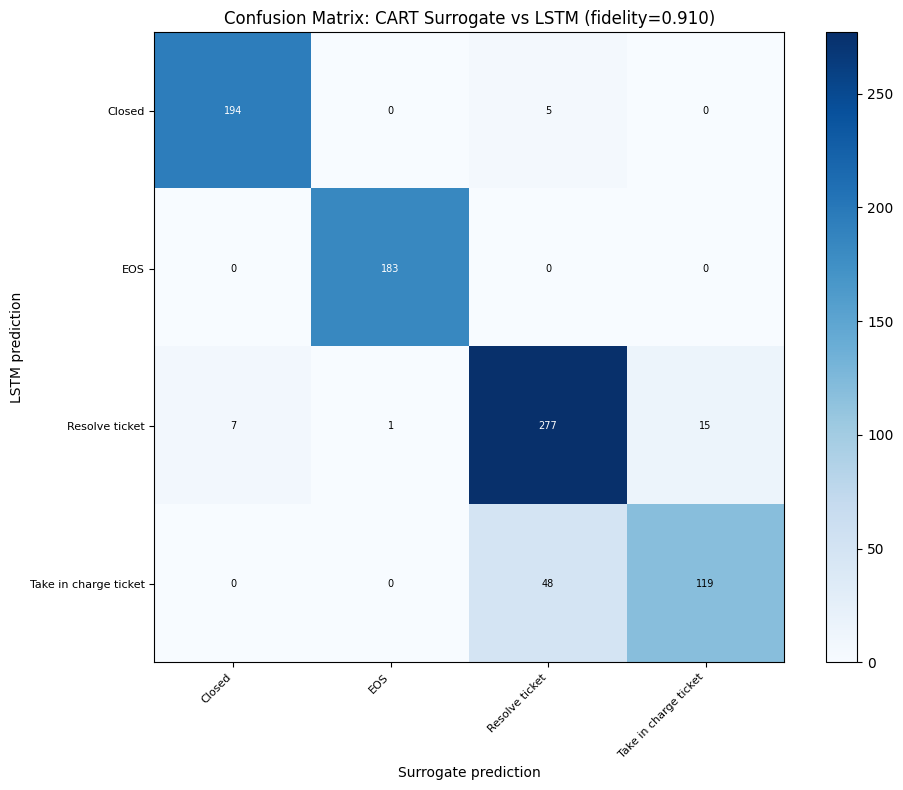

In [7]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

y_pred = clf_best.predict(X_test)
fidelity = (y_pred == y_test).mean()

print('=' * 60)
print(f'  OVERALL FIDELITY (surrogate vs LSTM): {fidelity:.4f}')
print('=' * 60)
print()
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion matrix
labels = sorted(set(y_test) | set(y_pred))
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Surrogate prediction')
ax.set_ylabel('LSTM prediction')
ax.set_title(f'Confusion Matrix: CART Surrogate vs LSTM (fidelity={fidelity:.3f})')
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=7)
plt.colorbar(im)
plt.tight_layout()
plt.show()

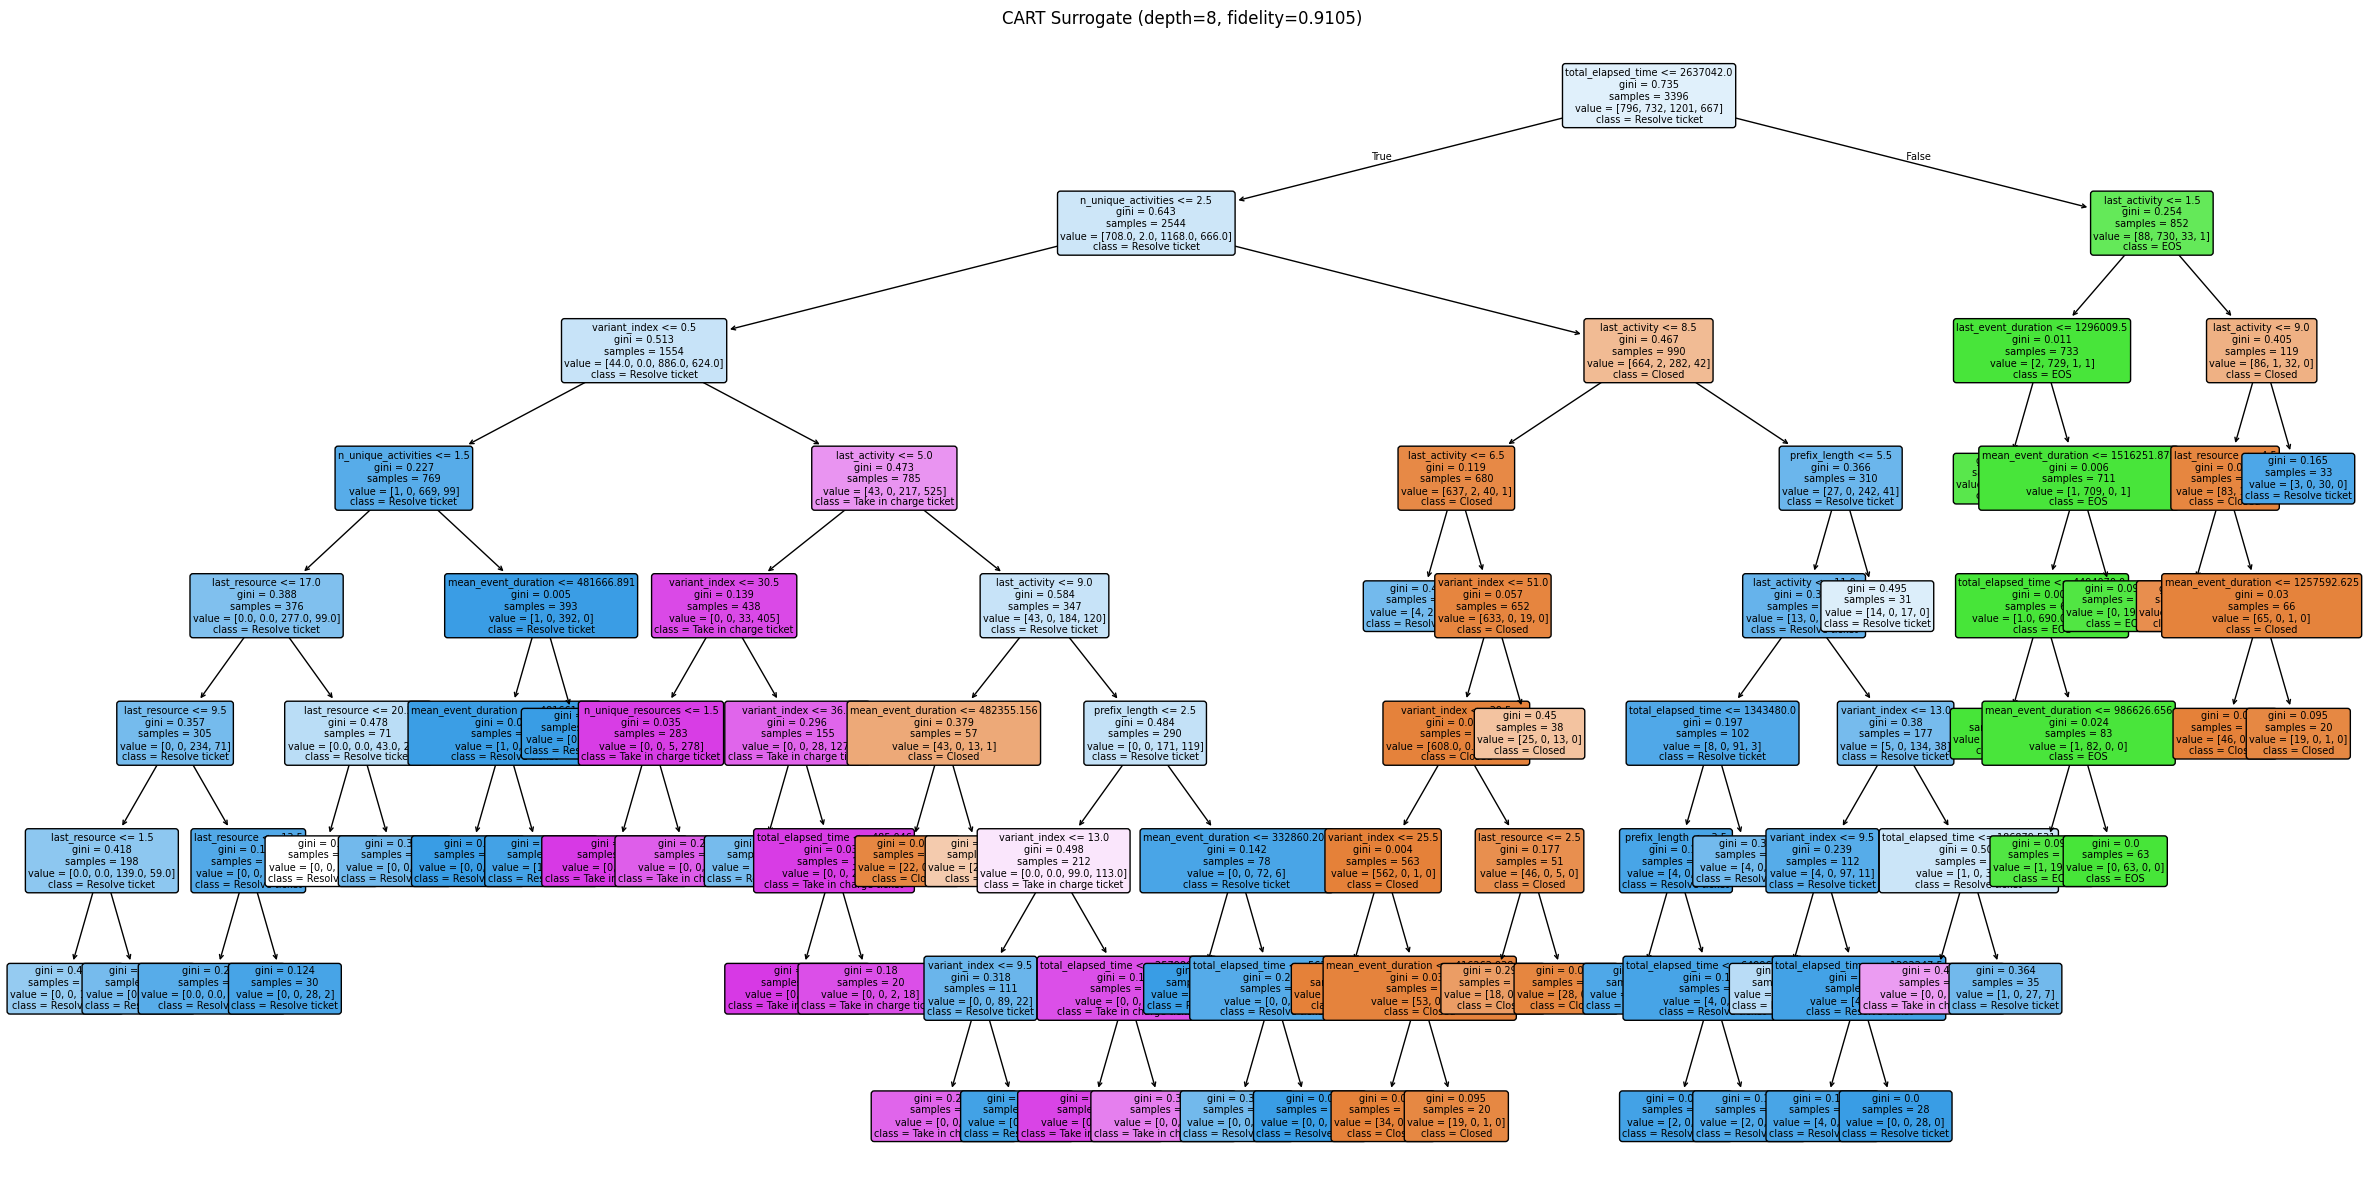

|--- total_elapsed_time <= 2637042.00
|   |--- n_unique_activities <= 2.50
|   |   |--- variant_index <= 0.50  [variant_index in {1.0}]
|   |   |   |--- n_unique_activities <= 1.50
|   |   |   |   |--- last_resource <= 17.00  [last_resource in {Value 1, Value 10, Value 11, Value 12, Value 13, Value 14, ... (18 total)}]
|   |   |   |   |   |--- last_resource <= 9.50  [last_resource in {Value 1, Value 10, Value 11, Value 12, Value 13, Value 14, ... (10 total)}]
|   |   |   |   |   |   |--- last_resource <= 1.50  [last_resource in {Value 1, Value 10}]
|   |   |   |   |   |   |   |--- class: Resolve ticket
|   |   |   |   |   |   |--- last_resource >  1.50  [last_resource in {Value 11, Value 12, Value 13, Value 14, Value 15, Value 16, ... (20 total)}]
|   |   |   |   |   |   |   |--- class: Resolve ticket
|   |   |   |   |   |--- last_resource >  9.50  [last_resource in {Value 19, Value 2, Value 20, Value 21, Value 22, Value 3, ... (12 total)}]
|   |   |   |   |   |   |--- last_resource <=

In [8]:
from sklearn.tree import plot_tree, export_text
import re

feature_names = list(X_encoded.columns)

# Plot tree
fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(clf_best, feature_names=feature_names,
          class_names=clf_best.classes_.tolist(),
          filled=True, rounded=True, ax=ax, fontsize=7)
ax.set_title(f'CART Surrogate (depth={best["max_depth"]}, fidelity={best["test_fidelity"]})')
plt.tight_layout()
plt.show()

# Text export with decoded category names
tree_text = export_text(clf_best, feature_names=feature_names)


def decode_tree_text(text, cat_cols, cat_mappings):
    """Replace ordinal split thresholds with actual category names."""
    decoded = []
    for line in text.split('\n'):
        out = line
        for col in cat_cols:
            pattern = rf'({re.escape(col)})\s*(<=|>)\s*([\d.]+)'
            m = re.search(pattern, line)
            if m:
                feat, op, thresh = m.group(1), m.group(2), float(m.group(3))
                cats = cat_mappings[feat]
                if op == '<=':
                    incl = [c for i, c in enumerate(cats) if i <= thresh]
                else:
                    incl = [c for i, c in enumerate(cats) if i > thresh]
                if len(incl) <= 8:
                    out += f'  [{feat} in {{{", ".join(incl)}}}]'
                else:
                    out += f'  [{feat} in {{{", ".join(incl[:6])}, ... ({len(incl)} total)}}]'
                break
        decoded.append(out)
    return '\n'.join(decoded)


print(decode_tree_text(tree_text, cat_cols, cat_mappings))

Feature importances (CART surrogate):


,feature,importance
5,total_elapsed_time,0.306052
1,last_activity,0.304050
3,n_unique_activities,0.188615
8,variant_index,0.178712
0,prefix_length,0.014500
9,last_resource,0.005508
7,mean_event_duration,0.001797
10,n_unique_resources,0.000648
6,last_event_duration,0.000117
2,first_activity,0.000000


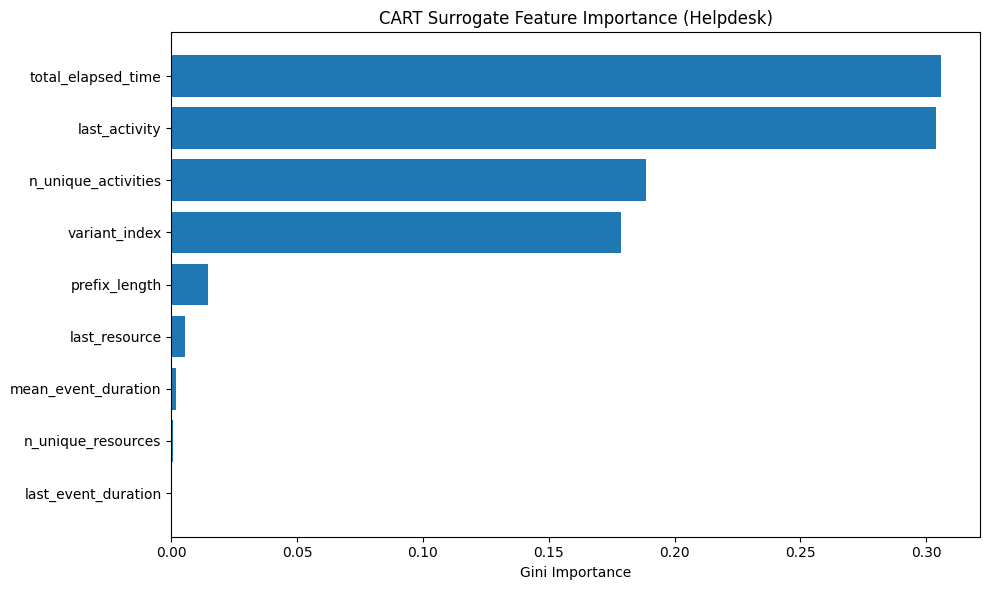

In [9]:
importances = clf_best.feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances,
}).sort_values('importance', ascending=False)

print('Feature importances (CART surrogate):')
display(importance_df)

fig, ax = plt.subplots(figsize=(10, 6))
imp_nz = importance_df[importance_df['importance'] > 0].copy()
ax.barh(imp_nz['feature'], imp_nz['importance'])
ax.set_xlabel('Gini Importance')
ax.set_title('CART Surrogate Feature Importance (Helpdesk)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
from sklearn.tree import _tree


def explain_decision_path(clf, sample, feature_names, cat_cols, cat_mappings):
    """Show the decision path for a single sample through the tree."""
    sample_df = sample.to_frame().T
    node_indicator = clf.decision_path(sample_df)
    node_ids = node_indicator.indices
    tree = clf.tree_

    steps = []
    for node_id in node_ids:
        if tree.feature[node_id] != _tree.TREE_UNDEFINED:
            feat_idx = tree.feature[node_id]
            feat_name = feature_names[feat_idx]
            threshold = tree.threshold[node_id]
            value = sample.iloc[feat_idx]
            direction = '<=' if value <= threshold else '>'

            step = f'{feat_name} = {value:.2f} {direction} {threshold:.2f}'

            if feat_name in cat_cols:
                cats = cat_mappings[feat_name]
                if direction == '<=':
                    incl = [c for i, c in enumerate(cats) if i <= threshold]
                else:
                    incl = [c for i, c in enumerate(cats) if i > threshold]
                preview = ', '.join(incl[:5])
                if len(incl) > 5:
                    preview += f', ... ({len(incl)} total)'
                step += f'  (categories: {preview})'
            steps.append(step)
    return steps


# Show decision paths for example prefixes
n_examples = 5
rng = np.random.RandomState(42)
example_positions = rng.choice(len(X_test), size=min(n_examples, len(X_test)), replace=False)

for pos in example_positions:
    sample = X_test.iloc[pos]
    lstm_label = y_test[pos]
    surrogate_pred = clf_best.predict(sample.to_frame().T)[0]
    match = 'MATCH' if lstm_label == surrogate_pred else 'MISMATCH'

    # Decode last_activity for display
    la_val = sample['last_activity']
    la_name = cat_mappings['last_activity'][int(la_val)] if 'last_activity' in cat_cols else la_val

    print(f'\n{"=" * 80}')
    print(f'LSTM: {lstm_label} | Surrogate: {surrogate_pred} [{match}]')
    print(f'prefix_len={sample["prefix_length"]:.0f}, last_activity={la_name}')

    path = explain_decision_path(clf_best, sample, feature_names, cat_cols, cat_mappings)
    for i, step in enumerate(path):
        print(f'  Step {i + 1}: {step}')
    print(f'  -> Prediction: {surrogate_pred}')


LSTM: Resolve ticket | Surrogate: EOS [MISMATCH]
prefix_len=3, last_activity=Assign seriousness
  Step 1: total_elapsed_time = 3809835.12 > 2637042.00
  Step 2: last_activity = 0.00 <= 1.50  (categories: Assign seriousness, Closed)
  Step 3: last_event_duration = 3809719.13 > 1296009.50
  Step 4: mean_event_duration = 1591046.13 > 1516251.88
  -> Prediction: EOS

LSTM: Take in charge ticket | Surrogate: Take in charge ticket [MATCH]
prefix_len=2, last_activity=Assign seriousness
  Step 1: total_elapsed_time = 431801.99 <= 2637042.00
  Step 2: n_unique_activities = 1.00 <= 2.50
  Step 3: variant_index = 15.00 > 0.50  (categories: 10.0, 11.0, 12.0, 13.0, 14.0, ... (56 total))
  Step 4: last_activity = 0.00 <= 5.00  (categories: Assign seriousness, Closed, Create SW anomaly, INVALID, Insert ticket, ... (6 total))
  Step 5: variant_index = 15.00 <= 30.50  (categories: 1.0, 10.0, 11.0, 12.0, 13.0, ... (31 total))
  Step 6: n_unique_resources = 2.00 > 1.50
  -> Prediction: Take in charge ti